## STEP 0 — Setup

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the Social Media Sentiment dataset
csv_path = Path("sentimentdataset copy.csv")

# Automatically use the only CSV in the notebook folder if the expected
# filename is not present.
if not csv_path.exists():
    csv_files = list(Path.cwd().glob("*.csv"))
    if len(csv_files) == 1:
        csv_path = csv_files[0]
    else:
        raise FileNotFoundError(
            "Social Media CSV not found. Put the CSV in the same folder "
            "as this notebook and name it 'Social_Media_Sentiment_Dataset.csv'."
        )

df = pd.read_csv(csv_path)

print("Dataset loaded from:", csv_path)
print("Shape:", df.shape)


Dataset loaded from: sentimentdataset copy.csv
Shape: (732, 15)


In [3]:
df.head()


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


## STEP 0.1 — Understand the dataset

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 225.0 KB


In [5]:
df.describe()
# This gives statistical information about the numeric columns.


,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


## STEP 0.2 — Clean the dataset

In [6]:
# Remove unnecessary index columns
df = df.drop(
    columns=["Unnamed: 0.1", "Unnamed: 0"],
    errors="ignore"
)

# Remove extra spaces from text/category columns
text_columns = df.select_dtypes(
    include="object"
).columns

for column in text_columns:
    df[column] = df[column].str.strip()

# Convert Timestamp into datetime
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

# Create an Engagement metric
df["Engagement"] = (
    df["Likes"] + df["Retweets"]
)

print("Cleaned dataset shape:", df.shape)


Cleaned dataset shape: (732, 14)


/var/folders/5x/xcp0cwgj27zb3ljw610qt91m0000gn/T/ipykernel_25680/1228900497.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(


## STEP 0.3 — Check the cleaned columns

In [7]:
print("Platforms:")
print(df["Platform"].unique())

print("\nNumber of Sentiment Categories:",
      df["Sentiment"].nunique())

print("\nMissing values:")
print(df.isnull().sum())


Platforms:
<ArrowStringArray>
['Twitter', 'Instagram', 'Facebook']
Length: 3, dtype: str

Number of Sentiment Categories: 191

Missing values:
Text          0
Sentiment     0
Timestamp     0
User          0
Platform      0
Hashtags      0
Retweets      0
Likes         0
Country       0
Year          0
Month         0
Day           0
Hour          0
Engagement    0
dtype: int64


In [8]:
df[[
    "Likes",
    "Retweets",
    "Engagement"
]].describe()


,Likes,Retweets,Engagement
count,732.000000,732.000000,732.000000
mean,42.901639,21.508197,64.409836
std,14.089848,7.061286,21.143994
min,10.000000,5.000000,15.000000
25%,34.750000,17.750000,52.500000
50%,43.000000,22.000000,65.000000
75%,50.000000,25.000000,75.000000
max,80.000000,40.000000,120.000000


## STEP 1 — Boxplot Using Seaborn

### STEP 1.1 — Prepare engagement data

In [9]:
plot_df = df[
    ["Platform", "Likes", "Retweets", "Engagement"]
].dropna()

plot_df.head()


,Platform,Likes,Retweets,Engagement
0,Twitter,30.0,15.0,45.0
1,Twitter,10.0,5.0,15.0
2,Instagram,40.0,20.0,60.0
3,Facebook,15.0,8.0,23.0
4,Instagram,25.0,12.0,37.0


In [ ]:
plot_df["Platform"].value_counts()


### STEP 1.2 — Create the Boxplot

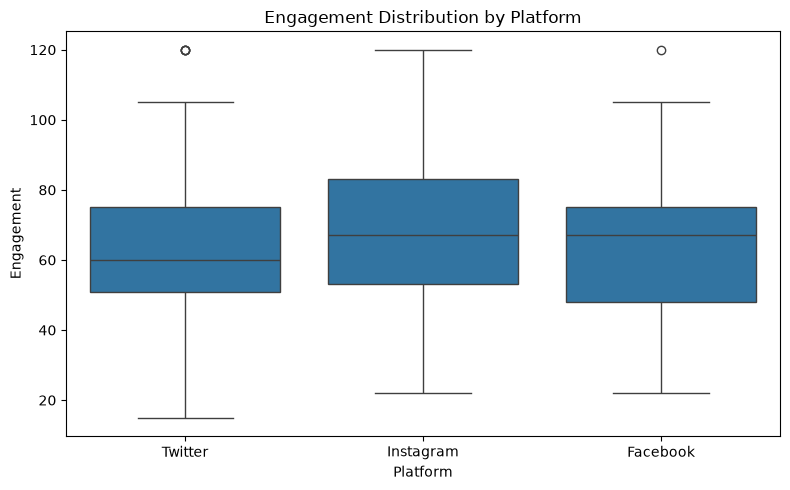

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x="Platform",
    y="Engagement"
)

plt.title(
    "Engagement Distribution by Platform"
)
plt.xlabel("Platform")
plt.ylabel("Engagement")

plt.tight_layout()
plt.show()


### STEP 1.3 — Create a Boxplot for Likes

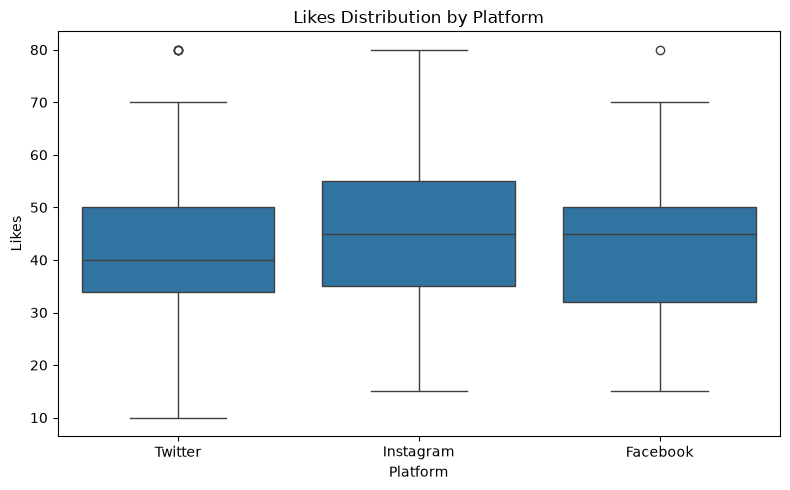

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x="Platform",
    y="Likes"
)

plt.title(
    "Likes Distribution by Platform"
)
plt.xlabel("Platform")
plt.ylabel("Likes")

plt.tight_layout()
plt.show()


## STEP 2 — Histogram + KDE

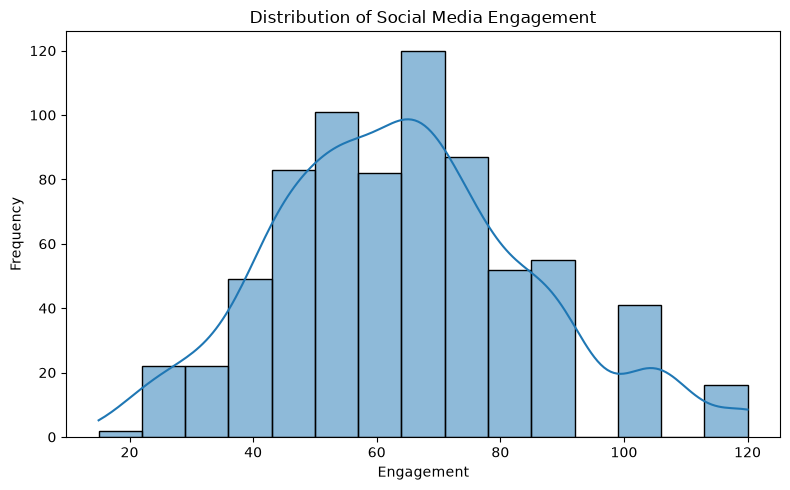

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Engagement",
    kde=True,
    bins=15
)

plt.title(
    "Distribution of Social Media Engagement"
)
plt.xlabel("Engagement")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## STEP 3 — Correlation Heatmap

In [13]:
nums_cols = [
    "Retweets",
    "Likes",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Engagement"
]

corr = df[nums_cols].corr()

corr


,Retweets,Likes,Year,Month,Day,Hour,Engagement
Retweets,1.000000,0.998482,-0.039982,0.073265,0.009213,0.196955,0.999326
Likes,0.998482,1.000000,-0.043415,0.066643,0.011489,0.195331,0.999831
Year,-0.039982,-0.043415,1.000000,-0.314845,0.021973,-0.087470,-0.042283
Month,0.073265,0.066643,-0.314845,1.000000,-0.135873,0.137835,0.068877
Day,0.009213,0.011489,0.021973,-0.135873,1.000000,0.044072,0.010733
Hour,0.196955,0.195331,-0.087470,0.137835,0.044072,1.000000,0.195940
Engagement,0.999326,0.999831,-0.042283,0.068877,0.010733,0.195940,1.000000


### STEP 3.1 — Create Heatmap

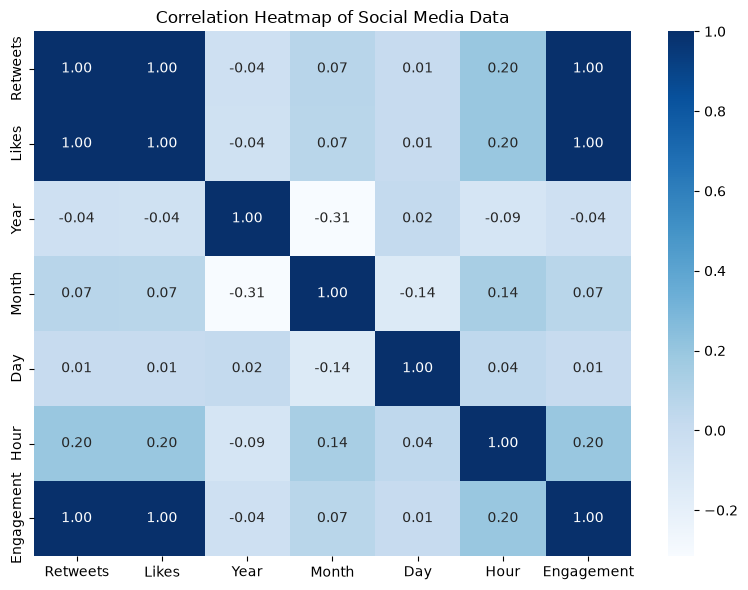

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title(
    "Correlation Heatmap of Social Media Data"
)

plt.tight_layout()
plt.show()


### Correlation values range from:

**-1 to +1**

- **+1** = strong positive relationship
- **0** = little or no linear relationship
- **-1** = strong negative relationship

The heatmap should be interpreted from the values produced by the actual dataset.

### For example, if:

- Likes and Retweets have a positive value, higher Likes tend to be associated with higher Retweets.
- Engagement and Likes have a positive value, Likes contribute strongly to Engagement because Engagement is calculated from Likes + Retweets.

These are interpretations of the calculated relationship, not a claim of causation.

## Step 4 — Violin Plot

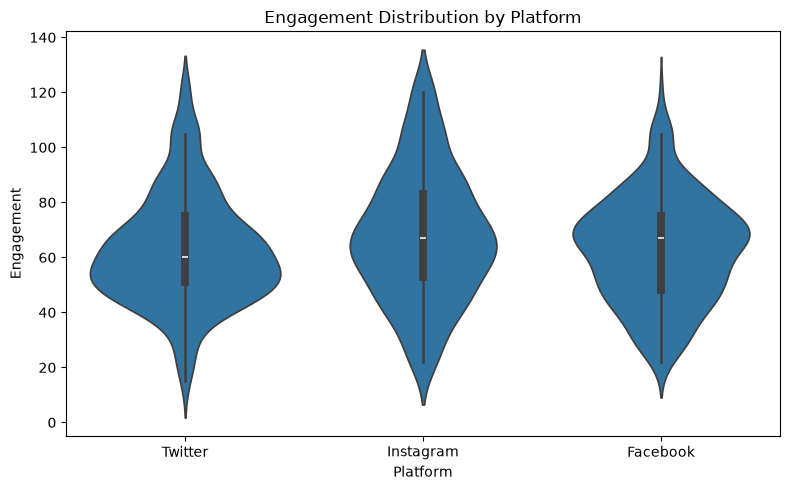

In [15]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Platform",
    y="Engagement"
)

plt.title(
    "Engagement Distribution by Platform"
)
plt.xlabel("Platform")
plt.ylabel("Engagement")

plt.tight_layout()
plt.show()


### Step 4.1 — Create a Violin Plot for Likes

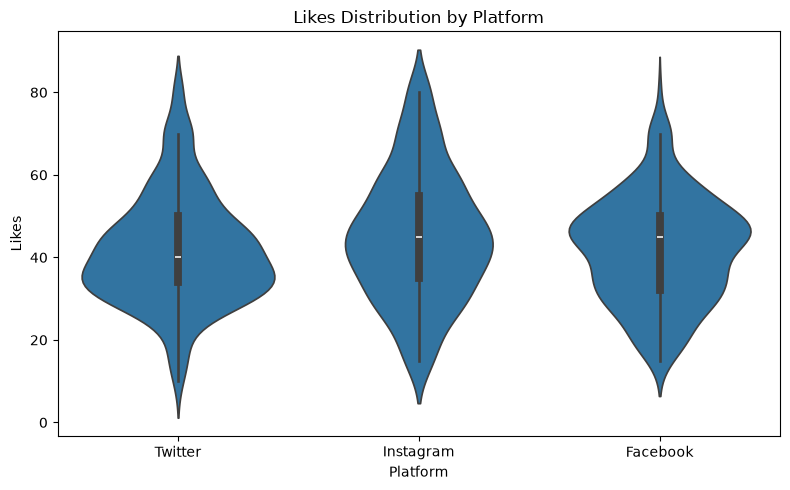

In [16]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Platform",
    y="Likes"
)

plt.title(
    "Likes Distribution by Platform"
)
plt.xlabel("Platform")
plt.ylabel("Likes")

plt.tight_layout()
plt.show()


## STEP 5 — Platform Analysis

In [17]:
platforms = df["Platform"].value_counts()

print("Posts by Platform:")
print(platforms)


Posts by Platform:
Platform
Instagram    258
Twitter      243
Facebook     231
Name: count, dtype: int64


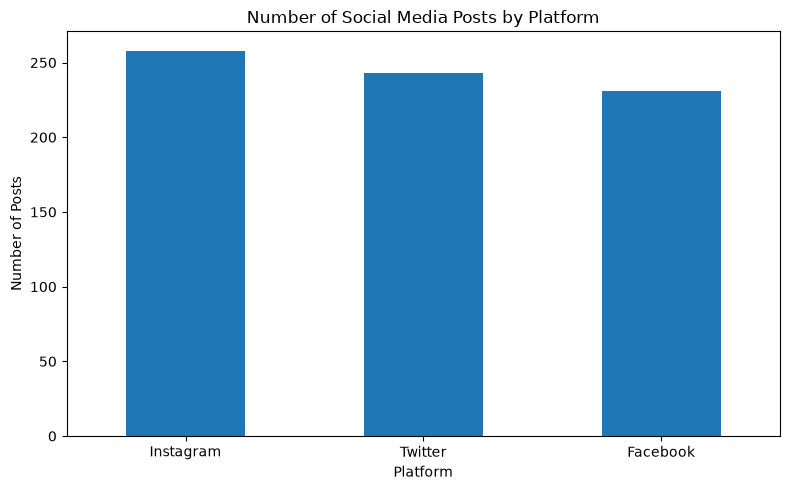

In [18]:
plt.figure(figsize=(8, 5))

platforms.plot(
    kind="bar"
)

plt.title(
    "Number of Social Media Posts by Platform"
)
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [19]:
platform_summary = df.groupby(
    "Platform"
)[
    ["Likes", "Retweets", "Engagement"]
].mean().round(2)

print(
    "Average Metrics by Platform:"
)
print(platform_summary)


Average Metrics by Platform:
           Likes  Retweets  Engagement
Platform                              
Facebook   41.87     20.97       62.84
Instagram  45.09     22.60       67.69
Twitter    41.56     20.86       62.42


## STEP 6 — Posts by Year

In [20]:
posts_by_year = (
    df["Year"]
    .value_counts()
    .sort_index()
)

print(posts_by_year)


Year
2010      3
2011      4
2012      4
2013      4
2014      4
2015     19
2016     38
2017     43
2018     56
2019     73
2020     69
2021     63
2022     63
2023    289
Name: count, dtype: int64


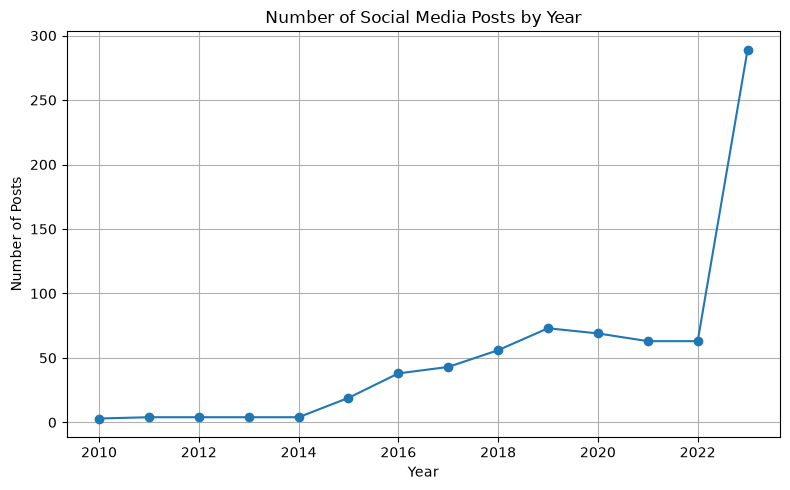

In [21]:
plt.figure(figsize=(8, 5))

posts_by_year.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Number of Social Media Posts by Year"
)
plt.xlabel("Year")
plt.ylabel("Number of Posts")
plt.grid(True)

plt.tight_layout()
plt.show()


## STEP 6.1 — Posts by Month

In [22]:
posts_by_month = (
    df["Month"]
    .value_counts()
    .sort_index()
)

print(posts_by_month)


Month
1     82
2     85
3     44
4     51
5     46
6     71
7     62
8     78
9     77
10    48
11    49
12    39
Name: count, dtype: int64


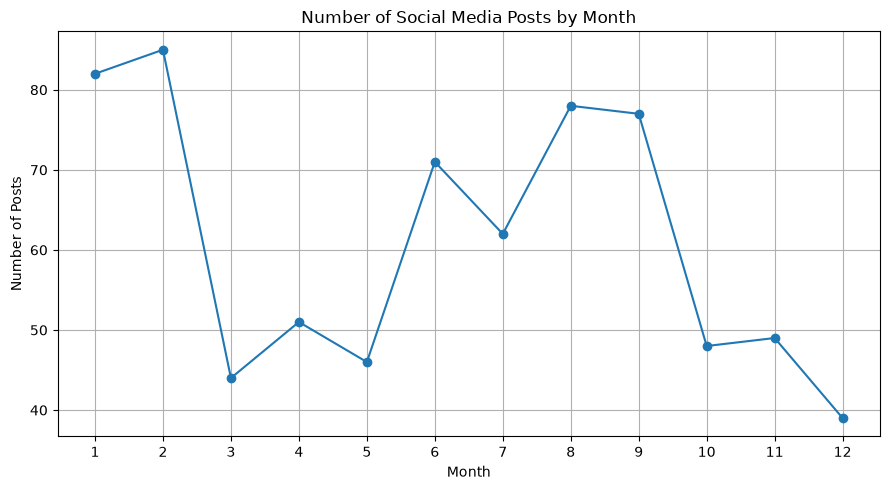

In [23]:
plt.figure(figsize=(9, 5))

posts_by_month.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Number of Social Media Posts by Month"
)
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()


## STEP 6.2 — Posts by Hour

In [24]:
posts_by_hour = (
    df["Hour"]
    .value_counts()
    .sort_index()
)

print(posts_by_hour)


Hour
0      1
2      1
3      3
5      1
6      4
7      7
8     23
9     28
10    30
11    37
12    38
13    30
14    94
15    47
16    69
17    48
18    65
19    75
20    50
21    41
22    33
23     7
Name: count, dtype: int64


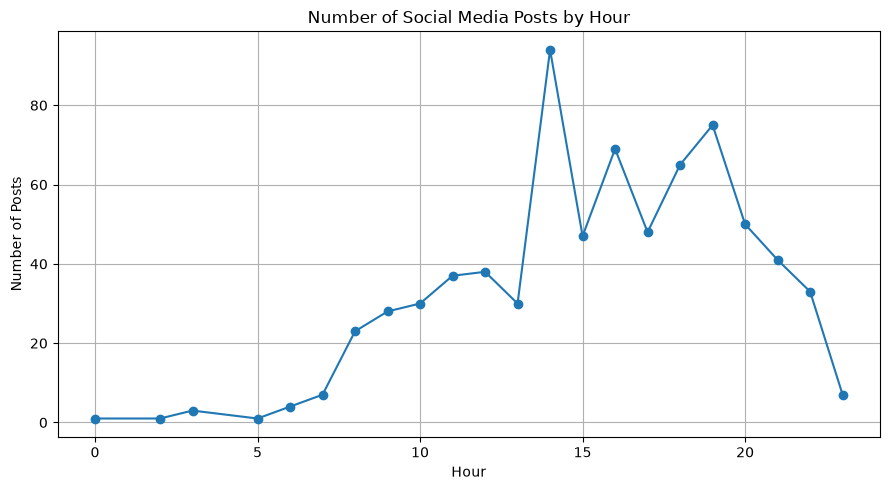

In [25]:
plt.figure(figsize=(9, 5))

posts_by_hour.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Number of Social Media Posts by Hour"
)
plt.xlabel("Hour")
plt.ylabel("Number of Posts")
plt.grid(True)

plt.tight_layout()
plt.show()


## STEP 7 — Top 15 Sentiments

In [26]:
top_sentiments = (
    df["Sentiment"]
    .value_counts()
    .head(15)
)

print(top_sentiments)


Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Despair        11
Nostalgia      11
Awe             9
Grief           9
Loneliness      9
Hopeful         9
Name: count, dtype: int64


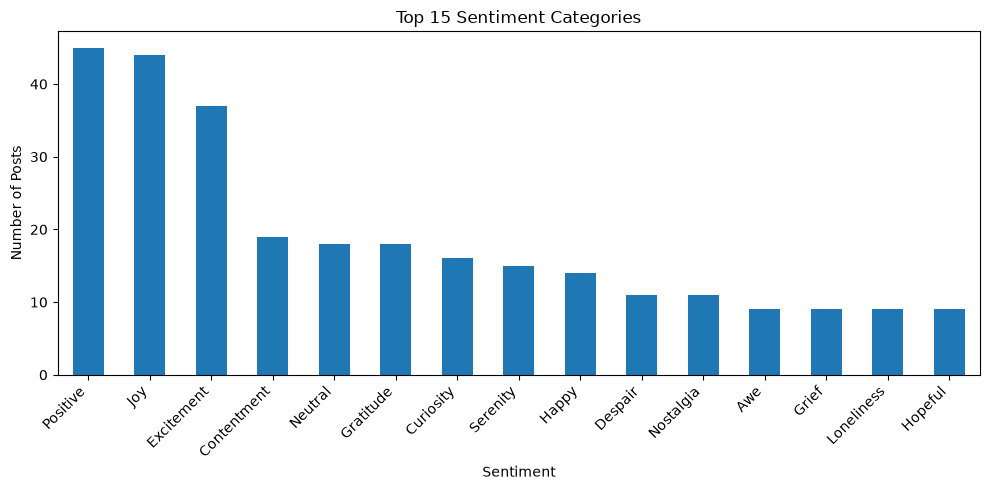

In [27]:
plt.figure(figsize=(10, 5))

top_sentiments.plot(
    kind="bar"
)

plt.title(
    "Top 15 Sentiment Categories"
)
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


## STEP 8 — Likes vs Retweets

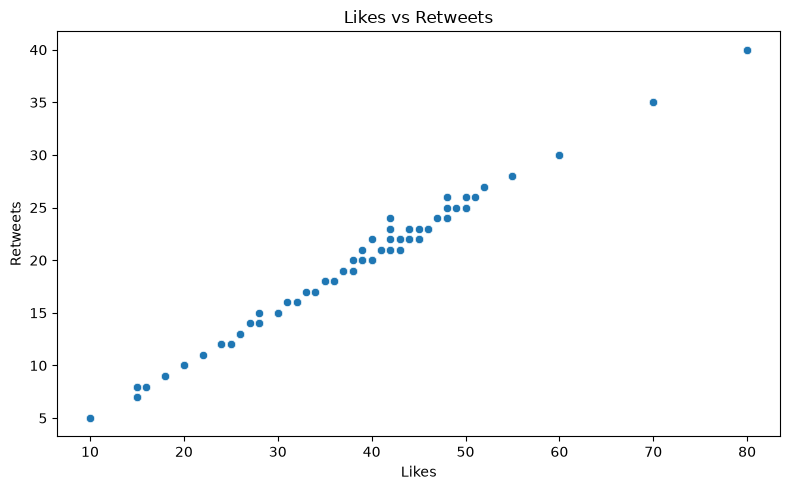

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Likes",
    y="Retweets"
)

plt.title(
    "Likes vs Retweets"
)
plt.xlabel("Likes")
plt.ylabel("Retweets")

plt.tight_layout()
plt.show()


## STEP 9 — Conclusion :-

In this lab, I analyzed the Social Media Sentiment dataset using Python, Pandas, Matplotlib, and Seaborn. I used different plots such as boxplots, histograms with KDE, correlation heatmaps, violin plots, platform-wise comparisons, yearly and monthly trend plots, and a Likes-versus-Retweets scatter plot.

The analysis examined the distribution of social-media engagement, differences between platforms, sentiment categories, and time-based activity. The Engagement metric was created from Likes and Retweets to provide an overall measure of interaction.

The visualizations help convert the raw social-media dataset into meaningful analytical insights while keeping the conclusions based on the actual dataset values.

### Dataset note

The supplied Social Media dataset contains 732 rows and 15 columns before cleaning. After removing the two unnecessary index columns and adding Engagement, the working dataset contains 732 rows and 14 columns. The original Sentiment labels are retained because the dataset contains multiple sentiment/emotion categories.